<div style="font-size: 14pt;">Prof. Krzysztof Rybinski</div><br/><br/>
<div style="font-size: 22pt;"><b>Applied Machine Learning course</b></div><br/><br/>
<div style="font-size: 18pt;">LAB 6</div><br/>
<div style="font-size: 18pt;">Unsupervised learning - clustering</div><br/>
<div style="font-size: 18pt;">- Hierarchical clustering</div><br/>
<div style="font-size: 18pt;">- KMeans clustering</div><br/>

In [28]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

In [29]:
#define plot dendrogram function
############################################################
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs, leaf_font_size=7)
############################################################

In [30]:
#check current folder
#os.chdir("C:/Users/THINK/Dysk Google/_Priv/Vistula_AML_course_2022/Python/")
df = pd.read_csv("Simple_clustering_data_example.csv", sep=';')
df

,Xaxis,Yaxis
0,1,1
1,3,5
2,5,6
3,6,12
4,12,24
5,11,22
6,14,26
7,21,21
8,22,18
9,24,24


In [31]:
#Try KMeans
kmeans = KMeans(n_clusters=3, max_iter = 10)
kmeans.fit(df)
labels = kmeans.predict(df)
centroids = kmeans.cluster_centers_

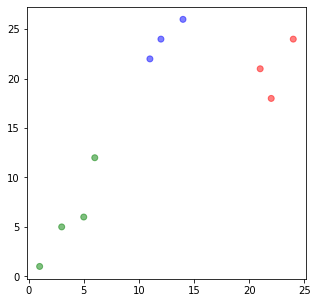

In [32]:
fig = plt.figure(figsize=(5, 5))
colmap = {1: 'r', 2: 'g', 3: 'b'} 
colors = list(map(lambda x: colmap[x+1], labels))
plt.scatter(df.iloc[:,0], df.iloc[:,1], color=colors, alpha=0.5, edgecolor=colors)

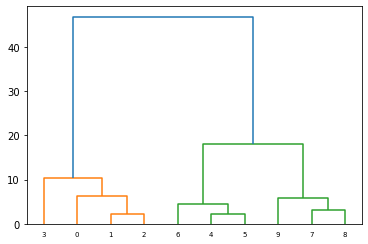

In [33]:
#Try h-clustering
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(df)
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode='level', p=3)

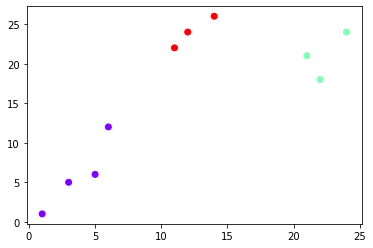

In [34]:
cluster = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
cluster.fit_predict(df)
cluster.labels_
plt.scatter(df.iloc[:,0],df.iloc[:,1], c=cluster.labels_, cmap='rainbow')

In [35]:
#lending club data https://www.lendingclub.com/
#check file "LC_data dictionary" for data description
#only small subset of features used for the class, 
#full dataset size is more than 1GB 
df = pd.read_csv("LendingClub_small.csv")
df
df.columns

Index(['loan_status', 'loan_amnt', 'int_rate', 'emp_length', 'annual_inc',
       'purpose', 'pub_rec', 'pub_rec_bankruptcies', 'home_mor', 'home_other',
       'home_rent', 'home_own'],
      dtype='object')

In [36]:
(df['purpose'].describe(),df['purpose'].unique())

(count                1340973
 unique                    14
 top       debt_consolidation
 freq                  778868
 Name: purpose, dtype: object,
 array(['debt_consolidation', 'credit_card', 'other', 'house', 'car',
        'home_improvement', 'moving', 'small_business', 'vacation',
        'medical', 'major_purchase', 'renewable_energy', 'wedding',
        'educational'], dtype=object))

In [37]:
#do one-hot encoding of purpose
purp = pd.get_dummies(df.purpose, prefix='purp')
purp

,purp_car,purp_credit_card,purp_debt_consolidation,purp_educational,purp_home_improvement,purp_house,purp_major_purchase,purp_medical,purp_moving,purp_other,purp_renewable_energy,purp_small_business,purp_vacation,purp_wedding
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340968,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340969,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340970,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340971,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [38]:
df.reset_index(inplace=True)
purp.reset_index(inplace=True)
df = pd.concat([df, purp], axis=1)
df.columns

Index(['index', 'loan_status', 'loan_amnt', 'int_rate', 'emp_length',
       'annual_inc', 'purpose', 'pub_rec', 'pub_rec_bankruptcies', 'home_mor',
       'home_other', 'home_rent', 'home_own', 'index', 'purp_car',
       'purp_credit_card', 'purp_debt_consolidation', 'purp_educational',
       'purp_home_improvement', 'purp_house', 'purp_major_purchase',
       'purp_medical', 'purp_moving', 'purp_other', 'purp_renewable_energy',
       'purp_small_business', 'purp_vacation', 'purp_wedding'],
      dtype='object')

In [39]:
#get target (loan status) variable, drop columns not used 
loan_status = df['loan_status']
df.drop(['loan_status', 'purpose', 'index', 'pub_rec_bankruptcies'], axis=1, inplace=True)
df.columns

Index(['loan_amnt', 'int_rate', 'emp_length', 'annual_inc', 'pub_rec',
       'home_mor', 'home_other', 'home_rent', 'home_own', 'purp_car',
       'purp_credit_card', 'purp_debt_consolidation', 'purp_educational',
       'purp_home_improvement', 'purp_house', 'purp_major_purchase',
       'purp_medical', 'purp_moving', 'purp_other', 'purp_renewable_energy',
       'purp_small_business', 'purp_vacation', 'purp_wedding'],
      dtype='object')

In [40]:
#normalize columns
cols_to_norm = ['loan_amnt', 'int_rate', 'emp_length', 'annual_inc', 'pub_rec']
df_old = df.copy()
df[cols_to_norm] = df[cols_to_norm].apply(lambda x: (x - x.mean()) / (x.std()))
df

,loan_amnt,int_rate,emp_length,annual_inc,pub_rec,home_mor,home_other,home_rent,home_own,purp_car,purp_credit_card,purp_debt_consolidation,purp_educational,purp_home_improvement,purp_house,purp_major_purchase,purp_medical,purp_moving,purp_other,purp_renewable_energy,purp_small_business,purp_vacation,purp_wedding
0,1.777561,1.887069,-0.392087,0.337745,1.297130,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,2.922335,0.589527,-1.162367,-0.442626,-0.356627,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0.632787,-1.203212,1.319647,0.337745,-0.356627,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,-1.141614,-0.419672,1.319647,-0.534852,-0.356627,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,-0.692290,2.915073,-0.734434,5.303744,-0.356627,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340968,0.403832,3.621303,1.319647,0.011408,-0.356627,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340969,0.398108,3.521010,1.319647,-0.318363,1.297130,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340970,0.060399,0.564454,-1.162367,0.124917,-0.356627,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340971,0.747264,3.681897,-1.247954,0.195860,-0.356627,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [41]:
df.describe()

,loan_amnt,int_rate,emp_length,annual_inc,pub_rec,home_mor,home_other,home_rent,home_own,purp_car,purp_credit_card,purp_debt_consolidation,purp_educational,purp_home_improvement,purp_house,purp_major_purchase,purp_medical,purp_moving,purp_other,purp_renewable_energy,purp_small_business,purp_vacation,purp_wedding
count,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06,1.340973e+06
mean,4.672953e-15,-7.473311e-12,-3.314704e-14,-3.696435e-14,-3.639359e-13,4.937131e-01,3.915068e-04,3.982713e-01,1.076241e-01,1.082125e-02,2.181737e-01,5.808230e-01,3.154426e-04,6.489467e-02,5.455740e-03,2.186099e-02,1.161470e-02,7.087391e-03,5.808767e-02,6.965092e-04,1.170792e-02,6.708562e-03,1.752459e-03
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.999607e-01,1.978266e-02,4.895421e-01,3.099052e-01,1.034609e-01,4.130061e-01,4.934246e-01,1.775791e-02,2.463400e-01,7.366124e-02,1.462296e-01,1.071439e-01,8.388781e-02,2.339092e-01,2.638228e-02,1.075679e-01,8.163064e-02,4.182570e-02
min,-1.599524e+00,-1.673336e+00,-1.247954e+00,-1.081112e+00,-3.566268e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,-7.409427e-01,-7.435353e-01,-9.056069e-01,-4.318427e-01,-3.566268e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,-2.830329e-01,-1.104352e-01,-2.209134e-01,-1.588546e-01,-3.566268e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,6.327866e-01,5.644537e-01,1.319647e+00,1.958596e-01,-3.566268e-01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2.922335e+00,3.692344e+00,1.319647e+00,1.549818e+02,1.418665e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [42]:
df

,loan_amnt,int_rate,emp_length,annual_inc,pub_rec,home_mor,home_other,home_rent,home_own,purp_car,purp_credit_card,purp_debt_consolidation,purp_educational,purp_home_improvement,purp_house,purp_major_purchase,purp_medical,purp_moving,purp_other,purp_renewable_energy,purp_small_business,purp_vacation,purp_wedding
0,1.777561,1.887069,-0.392087,0.337745,1.297130,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,2.922335,0.589527,-1.162367,-0.442626,-0.356627,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0.632787,-1.203212,1.319647,0.337745,-0.356627,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,-1.141614,-0.419672,1.319647,-0.534852,-0.356627,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,-0.692290,2.915073,-0.734434,5.303744,-0.356627,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340968,0.403832,3.621303,1.319647,0.011408,-0.356627,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340969,0.398108,3.521010,1.319647,-0.318363,1.297130,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340970,0.060399,0.564454,-1.162367,0.124917,-0.356627,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1340971,0.747264,3.681897,-1.247954,0.195860,-0.356627,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [43]:
#try h-clustering
model = AgglomerativeClustering()
model = model.fit(df)

MemoryError: Unable to allocate 6.54 TiB for an array with shape (899103622878,) and data type float64

In [44]:
#try KMeans
number_of_clusters = 7
kmeans = KMeans(n_clusters=number_of_clusters, max_iter = 20,  random_state=12345)
kmeans.fit(df)
cluster_no = pd.Series(kmeans.predict(df), name="cl_no")
centroids = kmeans.cluster_centers_

In [45]:
cluster_no

0          3
1          1
2          2
3          2
4          3
          ..
1340968    3
1340969    3
1340970    4
1340971    3
1340972    3
Name: cl_no, Length: 1340973, dtype: int32

In [46]:
#check if bad loans differ by cluster
for i in range(number_of_clusters):
    print("Cluster",i, " : ", loan_status.loc[cluster_no == i].mean())

Cluster 0  :  0.23909226085109397
Cluster 1  :  0.19502458945673118
Cluster 2  :  0.1745940715869334
Cluster 3  :  0.42135603111455877
Cluster 4  :  0.2833333333333333
Cluster 5  :  0.275
Cluster 6  :  0.12489030295021533


In [47]:
#add culster numbers to original data
df_cl = pd.concat([df_old, cluster_no], axis=1)
df_cl.columns

Index(['loan_amnt', 'int_rate', 'emp_length', 'annual_inc', 'pub_rec',
       'home_mor', 'home_other', 'home_rent', 'home_own', 'purp_car',
       'purp_credit_card', 'purp_debt_consolidation', 'purp_educational',
       'purp_home_improvement', 'purp_house', 'purp_major_purchase',
       'purp_medical', 'purp_moving', 'purp_other', 'purp_renewable_energy',
       'purp_small_business', 'purp_vacation', 'purp_wedding', 'cl_no'],
      dtype='object')

In [48]:
#collect cluster data
df_cl_0 = df_cl.loc[df_cl['cl_no'] == 0]
df_cl_1 = df_cl.loc[df_cl['cl_no'] == 1]
df_cl_2 = df_cl.loc[df_cl['cl_no'] == 2]
df_cl_3 = df_cl.loc[df_cl['cl_no'] == 3]
df_cl_4 = df_cl.loc[df_cl['cl_no'] == 4]
df_cl_5 = df_cl.loc[df_cl['cl_no'] == 5]
df_cl_6 = df_cl.loc[df_cl['cl_no'] == 6]
(df_cl_0.shape, df_cl_1.shape,df_cl_2.shape, df_cl_3.shape, df_cl_4.shape, df_cl_5.shape, df_cl_6.shape)

((141230, 24),
 (173855, 24),
 (312124, 24),
 (140513, 24),
 (278040, 24),
 (80, 24),
 (295131, 24))

In [49]:
#get feature means per cluster
cl0_m = df_cl_0.mean(); cl0_m.name = "Cluster_0"
cl1_m = df_cl_1.mean(); cl1_m.name = "Cluster_1"
cl2_m = df_cl_2.mean(); cl2_m.name = "Cluster_2"
cl3_m = df_cl_3.mean(); cl3_m.name = "Cluster_3"
cl4_m = df_cl_4.mean(); cl4_m.name = "Cluster_4"
cl5_m = df_cl_5.mean(); cl5_m.name = "Cluster_5"
cl6_m = df_cl_6.mean(); cl6_m.name = "Cluster_6"

In [50]:
pd.set_option('display.max_columns', None)
pd.concat([cl0_m, cl1_m, cl2_m, cl3_m, cl4_m, cl5_m, cl6_m] ,axis=1)

,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6
loan_amnt,10964.594810,28736.422594,11694.165460,22323.036125,9772.104373,1.621812e+04,11376.455540
int_rate,13.337456,12.021855,11.893542,21.654930,15.715593,1.150650e+01,9.353646
emp_length,4.418003,7.864801,14.851456,9.264225,3.043231,9.987500e+00,3.391736
annual_inc,65320.721329,140107.843869,72244.307652,77841.590880,51028.183024,5.729751e+06,69324.589678
pub_rec,1.428677,0.066090,0.169731,0.152669,0.003413,2.125000e-01,0.001759
home_mor,0.449784,0.699284,0.591150,0.557820,0.221572,5.875000e-01,0.516425
home_other,0.000333,0.000265,0.000301,0.000399,0.000500,0.000000e+00,0.000485
home_rent,0.439921,0.208720,0.294572,0.337371,0.667483,2.750000e-01,0.375078
home_own,0.109962,0.091732,0.113977,0.104410,0.110445,1.375000e-01,0.108013
purp_car,0.011740,0.003192,0.010983,0.003879,0.012991,5.000000e-02,0.015956


# Homework 5 
- implement Kmeans for different number of clusters (different than 4)
- check whether there are differences in loan status between clusters 
- analyze cluster characteristics and discuss how they explain differences in percentages on loans paid or not paid on time
- send your presentations with homework 5 and your Python code to rybinski@rybinski.eu by 23:59 on Monday, 25 April, 2022. 



In [51]:
#try KMeans
number_of_clusters = 6
kmeans = KMeans(n_clusters=number_of_clusters, max_iter = 20,  random_state=12345)
kmeans.fit(df)
cluster_no = pd.Series(kmeans.predict(df), name="cl_no")
centroids = kmeans.cluster_centers_

In [52]:
cluster_no

0          5
1          3
2          2
3          2
4          5
          ..
1340968    5
1340969    5
1340970    1
1340971    5
1340972    5
Name: cl_no, Length: 1340973, dtype: int32

In [53]:
#check if bad loans differ by cluster
for i in range(number_of_clusters):
    print("Cluster",i, " : ", loan_status.loc[cluster_no == i].mean())

Cluster 0  :  0.23593470322903987
Cluster 1  :  0.18021565326726693
Cluster 2  :  0.1750853030585024
Cluster 3  :  0.20445276231679751
Cluster 4  :  0.2702702702702703
Cluster 5  :  0.4136143053064669


In [54]:
#add culster numbers to original data
df_cl = pd.concat([df_old, cluster_no], axis=1)
df_cl.columns

Index(['loan_amnt', 'int_rate', 'emp_length', 'annual_inc', 'pub_rec',
       'home_mor', 'home_other', 'home_rent', 'home_own', 'purp_car',
       'purp_credit_card', 'purp_debt_consolidation', 'purp_educational',
       'purp_home_improvement', 'purp_house', 'purp_major_purchase',
       'purp_medical', 'purp_moving', 'purp_other', 'purp_renewable_energy',
       'purp_small_business', 'purp_vacation', 'purp_wedding', 'cl_no'],
      dtype='object')

In [55]:
#collect cluster data
df_cl_0 = df_cl.loc[df_cl['cl_no'] == 0]
df_cl_1 = df_cl.loc[df_cl['cl_no'] == 1]
df_cl_2 = df_cl.loc[df_cl['cl_no'] == 2]
df_cl_3 = df_cl.loc[df_cl['cl_no'] == 3]
df_cl_4 = df_cl.loc[df_cl['cl_no'] == 4]
df_cl_5 = df_cl.loc[df_cl['cl_no'] == 5]
(df_cl_0.shape, df_cl_1.shape,df_cl_2.shape, df_cl_3.shape, df_cl_4.shape, df_cl_5.shape)

((139670, 24),
 (483554, 24),
 (322380, 24),
 (205715, 24),
 (74, 24),
 (189580, 24))

In [56]:
#get feature means per cluster
cl0_m = df_cl_0.mean(); cl0_m.name = "Cluster_0"
cl1_m = df_cl_1.mean(); cl1_m.name = "Cluster_1"
cl2_m = df_cl_2.mean(); cl2_m.name = "Cluster_2"
cl3_m = df_cl_3.mean(); cl3_m.name = "Cluster_3"
cl4_m = df_cl_4.mean(); cl4_m.name = "Cluster_4"
cl5_m = df_cl_5.mean(); cl5_m.name = "Cluster_5"

In [57]:
pd.set_option('display.max_columns', None)
pd.concat([cl0_m, cl1_m, cl2_m, cl3_m, cl4_m, cl5_m] ,axis=1)

,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5
loan_amnt,10926.916482,10083.339658,11860.485142,28435.659407,1.515473e+04,17569.031675
int_rate,13.204218,11.571157,11.887013,12.465192,1.161676e+01,21.220688
emp_length,4.435827,3.117307,14.747379,7.983142,1.029730e+01,6.605457
annual_inc,65568.409418,60001.119186,72724.745220,133887.093044,5.951082e+06,66341.577455
pub_rec,1.435391,0.000000,0.167880,0.066976,2.162162e-01,0.109611
home_mor,0.450884,0.366865,0.603462,0.703862,6.081081e-01,0.434107
home_other,0.000322,0.000529,0.000298,0.000253,0.000000e+00,0.000401
home_rent,0.439099,0.522525,0.284338,0.205376,2.567568e-01,0.454373
home_own,0.109694,0.110081,0.111902,0.090509,1.351351e-01,0.111119
purp_car,0.011799,0.015611,0.010885,0.003184,5.405405e-02,0.006045


In [58]:
#try KMeans
number_of_clusters = 5
kmeans = KMeans(n_clusters=number_of_clusters, max_iter = 20,  random_state=12345)
kmeans.fit(df)
cluster_no = pd.Series(kmeans.predict(df), name="cl_no")
centroids = kmeans.cluster_centers_

In [59]:
cluster_no

0          0
1          0
2          2
3          2
4          0
          ..
1340968    0
1340969    0
1340970    1
1340971    0
1340972    1
Name: cl_no, Length: 1340973, dtype: int32

In [60]:
#check if bad loans differ by cluster
for i in range(number_of_clusters):
    print("Cluster",i, " : ", loan_status.loc[cluster_no == i].mean())

Cluster 0  :  0.2911403580017162
Cluster 1  :  0.21086424301030707
Cluster 2  :  0.18338450209277518
Cluster 3  :  0.2565187898521232
Cluster 4  :  0.2702702702702703


In [61]:
#add culster numbers to original data
df_cl = pd.concat([df_old, cluster_no], axis=1)
df_cl.columns

Index(['loan_amnt', 'int_rate', 'emp_length', 'annual_inc', 'pub_rec',
       'home_mor', 'home_other', 'home_rent', 'home_own', 'purp_car',
       'purp_credit_card', 'purp_debt_consolidation', 'purp_educational',
       'purp_home_improvement', 'purp_house', 'purp_major_purchase',
       'purp_medical', 'purp_moving', 'purp_other', 'purp_renewable_energy',
       'purp_small_business', 'purp_vacation', 'purp_wedding', 'cl_no'],
      dtype='object')

In [62]:
#collect cluster data
df_cl_0 = df_cl.loc[df_cl['cl_no'] == 0]
df_cl_1 = df_cl.loc[df_cl['cl_no'] == 1]
df_cl_2 = df_cl.loc[df_cl['cl_no'] == 2]
df_cl_3 = df_cl.loc[df_cl['cl_no'] == 3]
df_cl_4 = df_cl.loc[df_cl['cl_no'] == 4]

(df_cl_0.shape, df_cl_1.shape,df_cl_2.shape, df_cl_3.shape, df_cl_4.shape)

((283183, 24), (651495, 24), (369366, 24), (36855, 24), (74, 24))

In [63]:
#get feature means per cluster
cl0_m = df_cl_0.mean(); cl0_m.name = "Cluster_0"
cl1_m = df_cl_1.mean(); cl1_m.name = "Cluster_1"
cl2_m = df_cl_2.mean(); cl2_m.name = "Cluster_2"
cl3_m = df_cl_3.mean(); cl3_m.name = "Cluster_3"
cl4_m = df_cl_4.mean(); cl4_m.name = "Cluster_4"


In [64]:
pd.set_option('display.max_columns', None)
pd.concat([cl0_m, cl1_m, cl2_m, cl3_m, cl4_m] ,axis=1)

,Cluster_0,Cluster_1,Cluster_2,Cluster_3,Cluster_4
loan_amnt,27119.261573,10220.011013,12412.502437,13111.036494,1.515473e+04
int_rate,15.929949,12.745322,12.245832,14.140398,1.161676e+01
emp_length,7.431520,3.114431,14.529962,7.470438,1.029730e+01
annual_inc,115209.596613,59317.033483,74484.299989,80158.079439,5.951082e+06
pub_rec,0.103573,0.150852,0.171085,2.668783,2.162162e-01
home_mor,0.642461,0.365734,0.607971,0.467752,6.081081e-01
home_other,0.000321,0.000477,0.000301,0.000326,0.000000e+00
home_rent,0.262964,0.522567,0.280659,0.419726,2.567568e-01
home_own,0.094254,0.111221,0.111069,0.112196,1.351351e-01
purp_car,0.003143,0.014428,0.010236,0.011830,5.405405e-02
